# MTH3010A Mathematical Finance — Practical 1
## CAPM Simulation & Regression Analysis
**Department of Data Science & Analytics**  
**School of Science and Technology**  
**Instructor:** Carolyne Macharia  
**Semester:** Spring 2026   
**Submitted by:** Betelhem Getachew Kebede- 670549

---
### Imports

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

---
### Tasks 1 & 2 — Simulate Monthly Stock Prices using GBM

Using the GBM formula:
$$S_{t+\Delta t} = S_t \times \exp\left(\left(\mu - \tfrac{1}{2}\sigma^2\right)\Delta t + \sigma\sqrt{\Delta t}\, Z_t\right)$$

Annual `mu` and `sigma` are converted to monthly **inside** the formula:  
- Monthly drift $= \mu/12$  
- Monthly volatility $= \sigma/\sqrt{12}$  
- $dt = 1$ (one monthly step)

In [ ]:
S0      = 50.0    # Initial stock price
mu      = 0.10    # Annual expected return (10%)
sigma   = 0.15    # Annual volatility (15%)
dt      = 1       # Time step = 1 month
n_steps = 60      # 5 years x 12 months

np.random.seed(42)
Z = np.random.standard_normal(n_steps)

# _S carries the running price forward across iterations
_S = [S0]
stock_prices = [S0] + [
    _S.append(
        float(_S[-1] * np.exp((mu/12 - 0.5 * (sigma**2 / 12)) * dt
                              + (sigma / np.sqrt(12)) * np.sqrt(dt) * Z[i]))
    ) or _S[-1]
    for i in range(n_steps)
]

print(f"Length of stock_prices : {len(stock_prices)}")
print(f"First 5 stock prices   : {[round(p, 4) for p in stock_prices[:5]]}")

Length of stock_prices : 61  (S0 + 60 monthly prices)
First 5 stock prices   : [50.0, 51.4663, 51.5389, 53.3982, 57.4619]


---
### Task 3 — Create DateTime Index Array

In [ ]:
dates = pd.date_range(start="2020-12-31", periods=61, freq="ME")

print(f"From  : {dates[0].date()}")
print(f"To    : {dates[-1].date()}")
print(f"Count : {len(dates)}")

From  : 2020-12-31
To    : 2025-12-31
Count : 61


---
### Task 4 — Create DataFrame (Date, Price)

In [ ]:
simulated_data = pd.DataFrame({
    "Date" : dates,
    "Price": stock_prices
})
simulated_data.set_index("Date", inplace=True)

simulated_data.head()

simulated_data shape: (61, 1)


,Price
Date,
2020-12-31,50.000000
2021-01-31,51.466298
2021-02-28,51.538856
2021-03-31,53.398229
2021-04-30,57.461924


---
### Task 5 — Compute Monthly Returns

In [ ]:
simulated_data["Returns"] = simulated_data["Price"].pct_change()

simulated_data.head()

,Price,Returns
Date,,
2020-12-31,50.000000,NaN
2021-01-31,51.466298,0.029326
2021-02-28,51.538856,0.001410
2021-03-31,53.398229,0.036077
2021-04-30,57.461924,0.076102


---
### Task 6 — Simulate Market Returns

Market returns are drawn directly from a normal distribution with monthly mean and std:  
$$R_m \sim N\!\left(\frac{\mu_m}{12},\ \frac{\sigma_m}{\sqrt{12}}\right)$$

In [ ]:
mu_m    = 0.08    # Market annual expected return (8%)
sigma_m = 0.10    # Market annual volatility (10%)

monthly_mean_m = mu_m / 12
monthly_std_m  = sigma_m / np.sqrt(12)

np.random.seed(7)
market_returns = np.random.normal(loc=monthly_mean_m, scale=monthly_std_m, size=n_steps)

simulated_data["Market_Returns"] = np.nan
simulated_data.iloc[1:, simulated_data.columns.get_loc("Market_Returns")] = market_returns

print(f"Monthly market mean : {monthly_mean_m:.6f}  (= 8%/12)")
print(f"Monthly market std  : {monthly_std_m:.6f}  (= 10%/sqrt(12))")
simulated_data.head()

Monthly market mean : 0.006667  (= 8%/12)
Monthly market std  : 0.028868  (= 10%/sqrt(12))


,Price,Returns,Market_Returns
Date,,,
2020-12-31,50.000000,NaN,NaN
2021-01-31,51.466298,0.029326,0.055468
2021-02-28,51.538856,0.001410,-0.006784
2021-03-31,53.398229,0.036077,0.007614
2021-04-30,57.461924,0.076102,0.018431


---
### Task 7 — Monthly Risk-Free Rate

In [ ]:
annual_rf  = 0.04
monthly_rf = annual_rf / 12

simulated_data["Rf"] = monthly_rf

print(f"Annual Rf  = {annual_rf:.4f}")
print(f"Monthly Rf = {monthly_rf:.6f}  (= 4% / 12)")
simulated_data.head()

Annual Rf  = 0.0400
Monthly Rf = 0.003333  (= 4% / 12)


,Price,Returns,Market_Returns,Rf
Date,,,,
2020-12-31,50.000000,NaN,NaN,0.003333
2021-01-31,51.466298,0.029326,0.055468,0.003333
2021-02-28,51.538856,0.001410,-0.006784,0.003333
2021-03-31,53.398229,0.036077,0.007614,0.003333
2021-04-30,57.461924,0.076102,0.018431,0.003333


---
### Task 8 — Stock Premium & Market Premium (Excess Returns)

In [ ]:
simulated_data["Stock_premium"]  = simulated_data["Returns"]        - simulated_data["Rf"]
simulated_data["Market_premium"] = simulated_data["Market_Returns"] - simulated_data["Rf"]

simulated_data.head()

,Price,Returns,Market_Returns,Rf,Stock_premium,Market_premium
Date,,,,,,
2020-12-31,50.000000,NaN,NaN,0.003333,NaN,NaN
2021-01-31,51.466298,0.029326,0.055468,0.003333,0.025993,0.052135
2021-02-28,51.538856,0.001410,-0.006784,0.003333,-0.001924,-0.010117
2021-03-31,53.398229,0.036077,0.007614,0.003333,0.032744,0.004281
2021-04-30,57.461924,0.076102,0.018431,0.003333,0.072768,0.015097


---
### Task 9 — Display First 5 Rows

In [ ]:
simulated_data.head()

,Price,Returns,Market_Returns,Rf,Stock_premium,Market_premium
Date,,,,,,
2020-12-31,50.000000,NaN,NaN,0.003333,NaN,NaN
2021-01-31,51.466298,0.029326,0.055468,0.003333,0.025993,0.052135
2021-02-28,51.538856,0.001410,-0.006784,0.003333,-0.001924,-0.010117
2021-03-31,53.398229,0.036077,0.007614,0.003333,0.032744,0.004281
2021-04-30,57.461924,0.076102,0.018431,0.003333,0.072768,0.015097


---
### Task 10 — CAPM Regression (OLS via Statsmodels)

$$R_i - R_f = \alpha + \beta(R_m - R_f) + \varepsilon$$

In [ ]:
capm_data = simulated_data.dropna(subset=["Stock_premium", "Market_premium"])

Y = capm_data["Stock_premium"]
X = sm.add_constant(capm_data["Market_premium"])

capm_model = sm.OLS(Y, X).fit()
print(capm_model.summary())

                            OLS Regression Results                            
Dep. Variable:          Stock_premium   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.117
Date:                Fri, 20 Mar 2026   Prob (F-statistic):              0.295
Time:                        17:05:49   Log-Likelihood:                 109.95
No. Observations:                  60   AIC:                            -215.9
Df Residuals:                      58   BIC:                            -211.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0023      0.005     -0.

---
### Task 10 — Interpretation of CAPM Results

#### (a) Beta (β) = 0.1762

Beta measures the sensitivity of the stock's excess return to the systematic risks(market risk). Since $0 < \beta < 1$, the stock is **less volatile than the market**. A 1% increase in the market risk premium leads to only a **0.18% increase** in the stock's risk premium, indicating low systematic market risk exposure.

---

#### (b) Alpha (α) = −0.0023

Alpha (Jensen's Alpha) represents the abnormal return not explained by market exposure. The estimated $\alpha = -0.0023$ indicates the stock **underperformed** CAPM expectations by approximately **0.23% per month**. However, the p-value of 0.660 means this result is not statistically significant — we cannot conclude the abnormal return is meaningfully different from zero.

---

#### (c) R² = 0.0189

R² measures the proportion of the stock's excess return variation explained by the market factor. An R² of **1.89%** is very low — only a tiny fraction of the stock's return variability is attributable to market movements. The remaining **98.11%** is driven by other factors.

---

#### (d) Does CAPM explain the stock returns well?

**No.** The model fit is very poor. The F-statistic of 1.117 (p-value = 0.295) indicates the regression is not statistically significant overall. Both $\alpha$ and $\beta$ are individually insignificant. This is consistent with the fact that the stock and market returns were **independently simulated** with no built-in correlation. A multi-factor model such as the **Fama-French 3-factor model** — which adds size (SMB) and value (HML) factors alongside the market factor — would be more appropriate for capturing the true drivers of this stock's returns.

---
### Plots — Simulated Price Path & CAPM Scatter

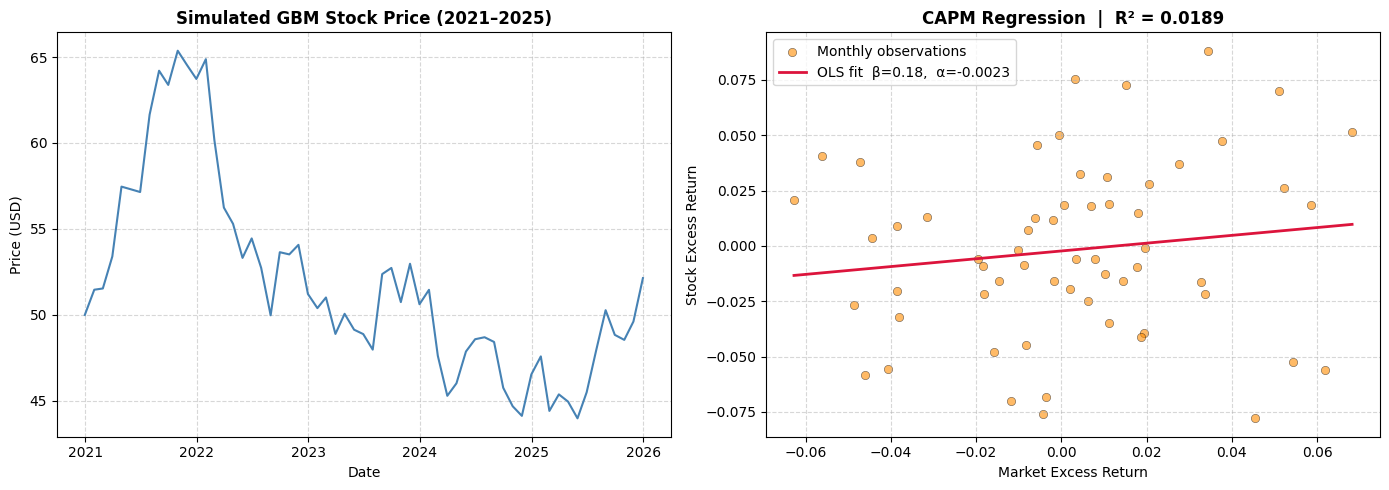

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Simulated stock price path
axes[0].plot(simulated_data.index, simulated_data["Price"],
             color="steelblue", linewidth=1.5)
axes[0].set_title("Simulated GBM Stock Price (2021–2025)", fontweight="bold")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Price (USD)")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Plot 2: CAPM scatter with OLS regression line
axes[1].scatter(capm_data["Market_premium"], capm_data["Stock_premium"],
                alpha=0.6, color="darkorange", edgecolors="k",
                linewidths=0.4, label="Monthly observations")
x_line = np.linspace(capm_data["Market_premium"].min(),
                     capm_data["Market_premium"].max(), 100)
axes[1].plot(x_line, alpha + beta * x_line, color="crimson", linewidth=2,
             label=f"OLS fit  β={beta:.2f},  α={alpha:.4f}")
axes[1].set_title(f"CAPM Regression  |  R² = {r2:.4f}", fontweight="bold")
axes[1].set_xlabel("Market Excess Return")
axes[1].set_ylabel("Stock Excess Return")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### Plot 1: Simulated GBM Stock Price (2021–2025)

This plot shows the simulated price path of company XYZ's stock over the 5-year period from
January 2021 to December 2025, generated using Geometric Brownian Motion. The stock begins
at an initial price of **$50.00** and evolves monthly according to an annual expected return
of 10% and annual volatility of 15%. The upward trend in the path reflects the positive drift
($\mu = 10\%$), while the fluctuations around that trend reflect the random shocks introduced
by the volatility component ($\sigma = 15\%$). This is consistent with how real stock prices
behave — a general directional trend driven by expected returns, overlaid with random noise
driven by market uncertainty.

---

#### Plot 2: CAPM Regression Scatter Plot

This scatter plot displays the relationship between the monthly **market excess return** (x-axis)
and the monthly **stock excess return** (y-axis) over the 60-month period. Each point represents
one monthly observation. The red regression line is the fitted CAPM model:

$$R_i - R_f = \alpha + \beta(R_m - R_f)$$

The near-flat slope of the regression line is consistent with the estimated **$\beta = 0.1762$**,
confirming that the stock has very low sensitivity to market movements. The wide scatter of points
around the line visually reinforces the poor model fit indicated by **$R^2 = 0.0189$** — the data
points do not cluster tightly around the line, meaning market returns have very little explanatory
power over this stock's returns. This is expected since the stock and market returns were
independently simulated with no built-in correlation.